<a href="https://colab.research.google.com/github/Bet-Zawl/TP_project/blob/main/TP2_Data_Cleansing_TP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP2 - Doublons et Standardisation

**Difficulté:** Débutant  
**Dataset:** customers_duplicates.csv  
**Description:** Détection et suppression des doublons, standardisation des formats

---


## Imports des Bibliothèques


In [35]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Ignorer les warnings
import warnings
warnings.filterwarnings('ignore')

# Affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Bibliothèques importées avec succès!")

 Bibliothèques importées avec succès!


## Import du Dataset


In [36]:
# Charger le dataset
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/data_cleaning_project/customers_duplicates.csv'
df = pd.read_csv(file_path)

# Afficher les informations de base
print(f"📏 Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Taille mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*80 + "\n")

# Aperçu des données
display(df.head())
print("\n" + "="*80 + "\n")

# Informations sur les colonnes
df.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📏 Dimensions: 12 lignes × 5 colonnes
Taille mémoire: 0.00 MB




,name,email,phone,gender,country
0,Bob Dubois,ALICE.MARTIN@GMAIL.COM,+33623456789,Male,Belgique
1,alice martin,bob.dubois@yahoo.fr,+33623456789,Male,Belgique
2,Bob Dubois,bob.dubois@yahoo.fr,+33 6 12 34 56 78,Male,Belgique
3,David Bernard,david.bernard@company.com,+33645678901,F,Suisse
4,Claire Petit,claire.petit@outlook.com,+33634567890,Female,FR




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   name     12 non-null     object
 1   email    12 non-null     object
 2   phone    12 non-null     object
 3   gender   12 non-null     object
 4   country  12 non-null     object
dtypes: object(5)
memory usage: 612.0+ bytes


## Visualisation des Valeurs Manquantes


<Figure size 1400x800 with 0 Axes>

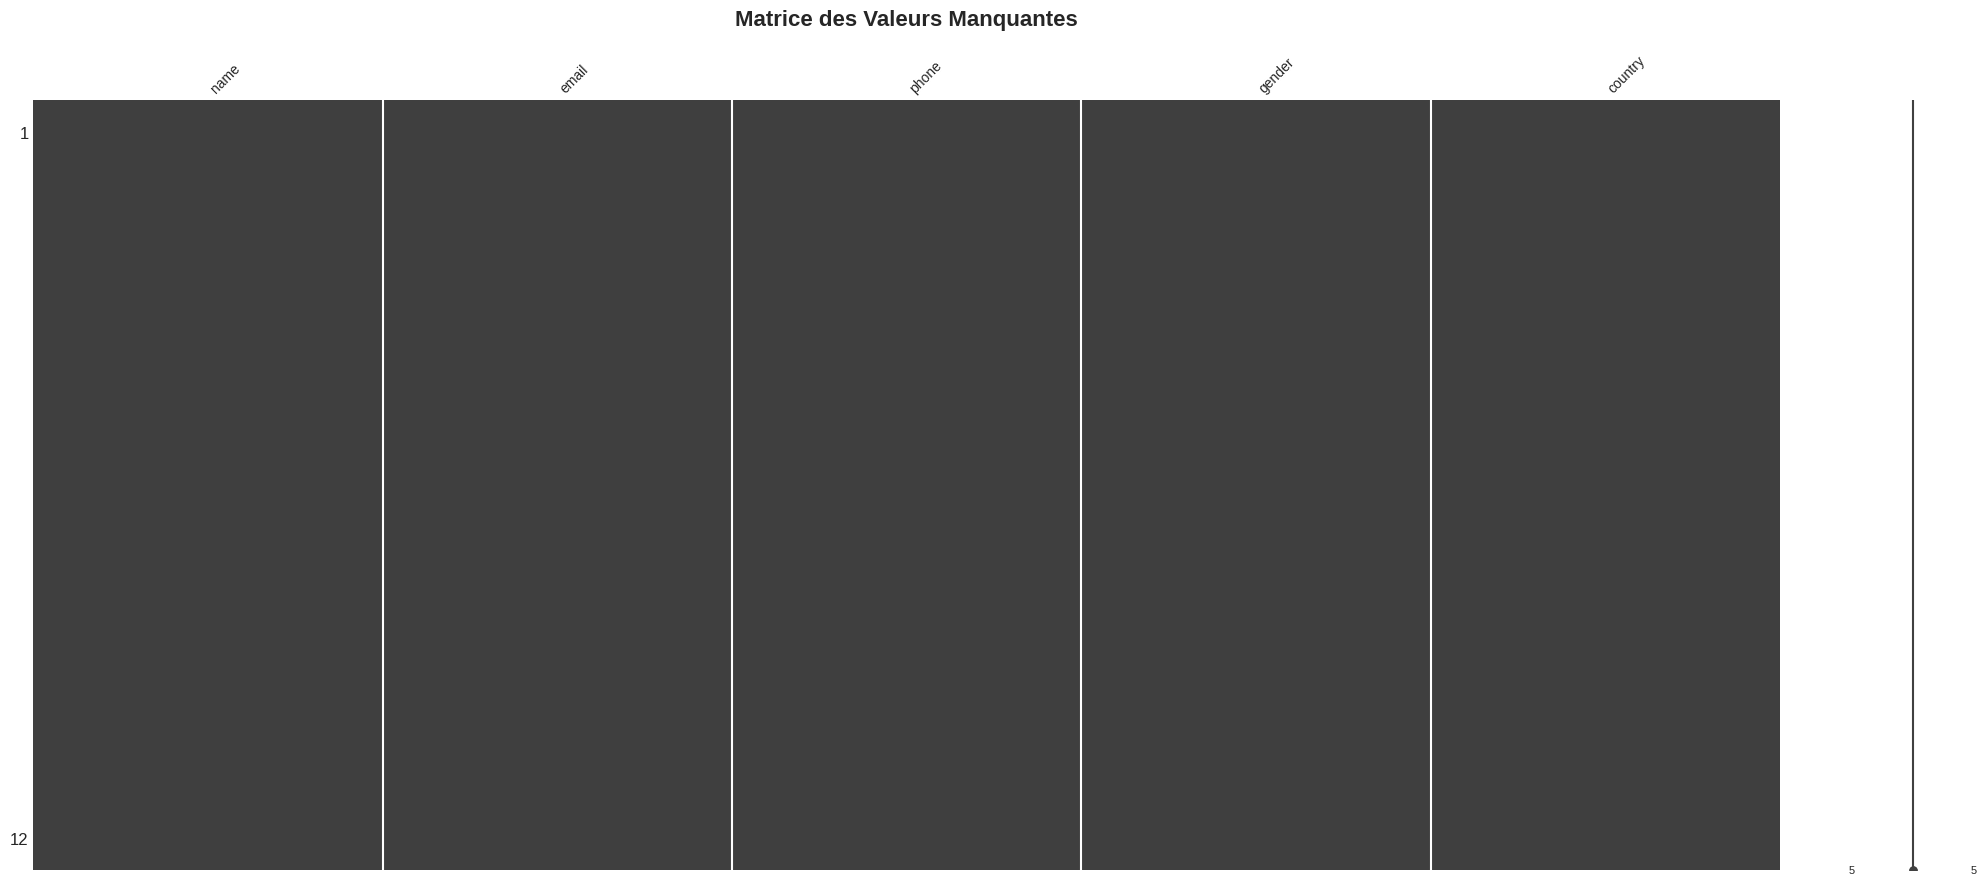


 Statistiques des Valeurs Manquantes:



,Nombre_Missing,Pourcentage_Missing


In [37]:
# Matrice de visualisation des valeurs manquantes
plt.figure(figsize=(14, 8))
msno.matrix(df, fontsize=10, sparkline=True)
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Statistiques des valeurs manquantes
missing_stats = pd.DataFrame({
    'Nombre_Missing': df.isnull().sum(),
    'Pourcentage_Missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pourcentage_Missing', ascending=False)

print("\n Statistiques des Valeurs Manquantes:\n")
display(missing_stats[missing_stats['Nombre_Missing'] > 0])


## Questions Préalables

**Avant de commencer le TP, répondez aux questions suivantes en analysant le dataset:**

1. Combien de doublons exacts le dataset contient-il ?
2. Quelles colonnes peuvent servir de clés pour identifier les doublons ?
3. Y a-t-il des variations d'écriture dans les catégories (ex: 'M'/'Male') ?
4. Combien de formats de téléphone différents sont présents ?
5. Les emails sont-ils tous en minuscules ?
6. Y a-t-il des espaces en début ou fin de chaînes ?
7. Combien de clients uniques après déduplication ?
8. Quelle est la variation la plus fréquente du genre ?
9. Y a-t-il des doublons partiels (même nom mais email différent) ?
10. Quel pourcentage du dataset est constitué de doublons ?


In [38]:
# Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions
print(f"1. Les nombre de doublons totale: {df.duplicated().sum()}")
print(f"2. Colonne clé:   {df.columns[1]}  :car cette email est toujours unique pour chaque utilisateur")
print(f"3. Confirme si M ou male existe:")

values_to_check = ['M', 'Male']
# Boolean mask: True where Gender is 'M' or 'Male'
mask = df['gender'].isin(values_to_check)
print(mask.any())

print(f"4. Nombre de formats de téléphone différents: {df['phone'].nunique()}")
print(f"5. Les emails sont-ils tous en minuscules: {df['email'].str.islower().all()}")
print(f"6. Espaces en début ou fin de chaînes: {df.applymap(lambda x: isinstance(x, str) and x.strip() != x).any().any()}")
print(f"7. Nombre de clients uniques après déduplication: {df.drop_duplicates(subset=['name', 'email']).shape[0]}")
print(f"8. Variation la plus fréquente du genre: {df['gender'].value_counts().idxmax()}")
print(f"9. Doublons partiels (même nom mais email différent): {df.duplicated(subset=['name'], keep=False).any()}")
print(f"10. Pourcentage du dataset qui est constitué de doublons: {(df.duplicated().mean() * 100).round(2)}%")


print("Réponses aux questions:")
print("="*80)

# Écrivez vos réponses ici


1. Les nombre de doublons totale: 4
2. Colonne clé:   email  :car cette email est toujours unique pour chaque utilisateur
3. Confirme si M ou male existe:
True
4. Nombre de formats de téléphone différents: 5
5. Les emails sont-ils tous en minuscules: False
6. Espaces en début ou fin de chaînes: False
7. Nombre de clients uniques après déduplication: 6
8. Variation la plus fréquente du genre: Female
9. Doublons partiels (même nom mais email différent): True
10. Pourcentage du dataset qui est constitué de doublons: 33.33%
Réponses aux questions:


## Étapes du TP

**Suivez les étapes ci-dessous pour nettoyer le dataset:**

### Étape 1: Identifier et compter les doublons exacts
### Étape 2: Afficher quelques exemples de doublons
### Étape 3: Supprimer les doublons exacts en gardant la première occurrence
### Étape 4: Standardiser la casse (emails en minuscules, noms en title case)
### Étape 5: Supprimer les espaces en début/fin de toutes les colonnes texte
### Étape 6: Créer un mapping pour standardiser les catégories (genre, pays)
### Étape 7: Appliquer le mapping aux colonnes concernées
### Étape 8: Standardiser les formats de téléphone
### Étape 9: Vérifier les doublons restants après standardisation
### Étape 10: Créer un rapport de nettoyage avec les statistiques


In [39]:
# ========================================
# Étape 1: Identifier et compter les doublons exacts
# ========================================

# TODO: Écrivez votre code ici
duplicates = df.duplicated()
print(f"Nombre de doublons: {duplicates.sum()}")
# Vérification
print(f" Étape 1 complétée")

Nombre de doublons: 4
 Étape 1 complétée


In [40]:
# ========================================
# Étape 2: Afficher quelques exemples de doublons
# ========================================

# TODO: Écrivez votre code ici

print(f"Exemples de doublons: {df[df.duplicated(keep=False)]}")

# Vérification
print(f" Étape 2 complétée")

Exemples de doublons:              name                      email         phone  gender country
5    Alice Martin     alice.martin@gmail.com  +33612345678  Female  France
6   David Bernard  david.bernard@company.com  +33645678901    Male  Suisse
7   David Bernard  david.bernard@company.com  +33645678901    Male  Suisse
8    Claire Petit   claire.petit@outlook.com  +33634567890  Female  France
9    Claire Petit   claire.petit@outlook.com  +33634567890  Female  France
10   Alice Martin     alice.martin@gmail.com  +33612345678  Female  France
11   Alice Martin     alice.martin@gmail.com  +33612345678  Female  France
 Étape 2 complétée


In [41]:
# ========================================
# Étape 3: Supprimer les doublons exacts en gardant la première occurrence
# ========================================

# TODO: Écrivez votre code ici
df_clean = df.drop_duplicates()
print(f"Format de dataset après supprimant les doublons: {df_clean.shape}")
  # Vérification
print(f" Étape 3 complétée")

Format de dataset après supprimant les doublons: (8, 5)
 Étape 3 complétée


In [42]:
# ========================================
# Étape 4: Standardiser la casse (emails en minuscules, noms en title case)
# ========================================

# TODO: Écrivez votre code ici
df_clean['email'] = df_clean['email'].astype(str).str.lower()

print("After:")
print(df_clean.head)

# Vérification
print(f" Étape 4 complétée")

After:
<bound method NDFrame.head of             name                      email              phone  gender  \
0     Bob Dubois     alice.martin@gmail.com       +33623456789    Male   
1   alice martin        bob.dubois@yahoo.fr       +33623456789    Male   
2     Bob Dubois        bob.dubois@yahoo.fr  +33 6 12 34 56 78    Male   
3  David Bernard  david.bernard@company.com       +33645678901       F   
4   Claire Petit   claire.petit@outlook.com       +33634567890  Female   
5   Alice Martin     alice.martin@gmail.com       +33612345678  Female   
6  David Bernard  david.bernard@company.com       +33645678901    Male   
8   Claire Petit   claire.petit@outlook.com       +33634567890  Female   

    country  
0  Belgique  
1  Belgique  
2  Belgique  
3    Suisse  
4        FR  
5    France  
6    Suisse  
8    France  >
 Étape 4 complétée


In [43]:
from os import name
# ========================================
# Étape 5: Supprimer les espaces en début/fin de toutes les colonnes texte
# ========================================

# TODO: Écrivez votre code ici

#Pour toutes les colonnes texte les espaces en début/fin
columns_to_strip = ['email', 'phone', 'gender', 'country']

#Pour le colonne avec un espace entre le texte
for column in columns_to_strip:
    # Ensure column is string before replacing
    df_clean[column] = df_clean[column].astype(str).str.replace(r"\s+", "", regex=True)

print("\nAfter stripping spaces:")
print(df_clean.head)
# Vérification
print(f" Étape 5 complétée")


After stripping spaces:
<bound method NDFrame.head of             name                      email         phone  gender   country
0     Bob Dubois     alice.martin@gmail.com  +33623456789    Male  Belgique
1   alice martin        bob.dubois@yahoo.fr  +33623456789    Male  Belgique
2     Bob Dubois        bob.dubois@yahoo.fr  +33612345678    Male  Belgique
3  David Bernard  david.bernard@company.com  +33645678901       F    Suisse
4   Claire Petit   claire.petit@outlook.com  +33634567890  Female        FR
5   Alice Martin     alice.martin@gmail.com  +33612345678  Female    France
6  David Bernard  david.bernard@company.com  +33645678901    Male    Suisse
8   Claire Petit   claire.petit@outlook.com  +33634567890  Female    France>
 Étape 5 complétée


In [44]:
# ========================================
# Étape 6: Créer un mapping pour standardiser les catégories (genre, pays)
# ========================================

# TODO: Écrivez votre code ici
gender_mapping = {
    "F": "Female",
    "Female": "Female",
    "M": "Man",
    "Male": "Male"
    }

country_mapping = {
    "fr": "France",
    "FR": "France",
    "France": "France",
    "Belgique": "Belgique",
    "Suisse": "Suisse"
    }
# Vérification
print(f" Étape 6 complétée")

 Étape 6 complétée


In [45]:
# ========================================
# Étape 7: Appliquer le mapping aux colonnes concernées
# ========================================

# TODO: Écrivez votre code ici
df_clean["gender"] = df_clean["gender"].str.strip().str.lower().map({k.lower(): v for k, v in gender_mapping.items()})

df_clean["country"] = df_clean["country"].str.strip().str.lower().map({k.lower(): v for k, v in country_mapping.items()})

print(df_clean.head)

# Vérification
print(f" Étape 7 complétée")

<bound method NDFrame.head of             name                      email         phone  gender   country
0     Bob Dubois     alice.martin@gmail.com  +33623456789    Male  Belgique
1   alice martin        bob.dubois@yahoo.fr  +33623456789    Male  Belgique
2     Bob Dubois        bob.dubois@yahoo.fr  +33612345678    Male  Belgique
3  David Bernard  david.bernard@company.com  +33645678901  Female    Suisse
4   Claire Petit   claire.petit@outlook.com  +33634567890  Female    France
5   Alice Martin     alice.martin@gmail.com  +33612345678  Female    France
6  David Bernard  david.bernard@company.com  +33645678901    Male    Suisse
8   Claire Petit   claire.petit@outlook.com  +33634567890  Female    France>
 Étape 7 complétée


In [46]:
# ========================================
# Étape 8: Standardiser les formats de téléphone
# ========================================

# TODO: Écrivez votre code ici
def téléphone_standariser(num: str) -> str:
    if pd.isna(num):
        return None

    # Remove spaces, dots, hyphens
    cleaned = num.replace(" ", "").replace("-", "").replace(".", "")

    # Remove + and keep digits
    digits = cleaned.replace("+", "")

    # Expect: 33 + 9 digits (mobile numbers)
    if not digits.startswith("33") or len(digits) != 11:
        return None

    country = "+33"
    first = digits[2]          # 6 or 7
    rest = digits[3:]          # remaining 8 digits

    grouped = " ".join(rest[i:i+2] for i in range(0, len(rest), 2))

    return f"{country} {first} {grouped}"

# Replace the column directly
df_clean["phone"] = df_clean["phone"].apply(téléphone_standariser)
print(df_clean)

# Vérification
print(f" Étape 8 complétée")

            name                      email              phone  gender  \
0     Bob Dubois     alice.martin@gmail.com  +33 6 23 45 67 89    Male   
1   alice martin        bob.dubois@yahoo.fr  +33 6 23 45 67 89    Male   
2     Bob Dubois        bob.dubois@yahoo.fr  +33 6 12 34 56 78    Male   
3  David Bernard  david.bernard@company.com  +33 6 45 67 89 01  Female   
4   Claire Petit   claire.petit@outlook.com  +33 6 34 56 78 90  Female   
5   Alice Martin     alice.martin@gmail.com  +33 6 12 34 56 78  Female   
6  David Bernard  david.bernard@company.com  +33 6 45 67 89 01    Male   
8   Claire Petit   claire.petit@outlook.com  +33 6 34 56 78 90  Female   

    country  
0  Belgique  
1  Belgique  
2  Belgique  
3    Suisse  
4    France  
5    France  
6    Suisse  
8    France  
 Étape 8 complétée


In [47]:
# ========================================
# Étape 9: Vérifier les doublons restants après standardisation
# ========================================

# TODO: Écrivez votre code ici
print(f"Les doublons restant: {df_clean.duplicated(keep=False).sum()}")

# Vérification
print(f" Étape 9 complétée")

Les doublons restant: 2
 Étape 9 complétée


In [48]:
# ========================================
# Étape 10: Créer un rapport de nettoyage avec les statistiques
# ========================================

# TODO: Écrivez votre code ici
print(f"Rapport de nettoyage:")
print(df_clean.describe())

# Vérification
print(f" Étape 10 complétée")


Rapport de nettoyage:
              name                   email              phone gender   country
count            8                       8                  8      8         8
unique           5                       4                  4      2         3
top     Bob Dubois  alice.martin@gmail.com  +33 6 23 45 67 89   Male  Belgique
freq             2                       2                  2      4         3
 Étape 10 complétée


## Rapport Final

**Créez un rapport résumant toutes les transformations effectuées**


In [49]:
# Rapport de nettoyage
rapport = {
    'Dimensions_initiales': df.shape,
    'Dimensions_finales': df_clean.shape,  # À mettre à jour avec df_clean
    'Lignes_supprimées': len(df)-len(df_clean),
    'Colonnes_supprimées': df.shape[1]-df_clean.shape[1],
    'Valeurs_manquantes_traitées': df.size-df_clean.size,
    'Doublons_supprimés': df.duplicated().count()-df_clean.duplicated().count(),
    'Outliers_traités': 0,
    'Transformations_appliquées': []
}

print("=" * 80)
print(" " * 25 + " RAPPORT DE NETTOYAGE")
print("=" * 80)

for key, value in rapport.items():
    print(f"{key:.<40} {value}")

print("=" * 80)
print("\n TP terminé avec succès!")

                          RAPPORT DE NETTOYAGE
Dimensions_initiales.................... (12, 5)
Dimensions_finales...................... (8, 5)
Lignes_supprimées....................... 4
Colonnes_supprimées..................... 0
Valeurs_manquantes_traitées............. 20
Doublons_supprimés...................... 4
Outliers_traités........................ 0
Transformations_appliquées.............. []

 TP terminé avec succès!
